# ChatGPT Reviews Analysis

In this project, we will analyze user reviews of the ChatGPT application.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS0w4_ZZtb4mjjgq_7FgaX88jp3Bzb-2bVwHcGKhqK1OA&s=10' width='750'>

In [1]:
#Libraries
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

### EDA 

In [2]:
df=pd.read_csv('chatgpt_reviews.csv')

In [3]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [4]:
df.tail()

,Review Id,Review,Ratings,Review Date
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,2023-07-27 16:26:31
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,2023-09-23 16:25:18
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,2023-11-08 13:57:14
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,2023-07-25 15:32:57
196726,0151001d-b81c-41b5-8927-f56738989625,expert application,5,2023-11-30 18:11:41


In [5]:
df.shape

(196727, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [7]:
df.isnull().sum()

Review Id      0
Review         6
Ratings        0
Review Date    0
dtype: int64

In [8]:
df['Review'] = df['Review'].str.lower() # Convert to lowercase
df['Review'] = df['Review'].str.replace('[^\w\s]', '', regex=True) # Remove punctuation marks
df['Review'] = df['Review'].str.replace('\d+', '', regex=True) # Remove digits/numbers
df['Review'] = df['Review'].str.replace('\n', '', regex=True) # Remove newlines
df['Review'] = df['Review'].str.replace('\r', '', regex=True) # Remove carriage returns

In [9]:
df['Review'][666]

'its just woow the best ever it also helps me with trading forex so i love it its just my partner'

In [10]:
df['Review'] = df['Review'].astype(str).fillna('')

In [11]:
df.drop(columns=['Review Id', 'Review Date'], inplace=True)

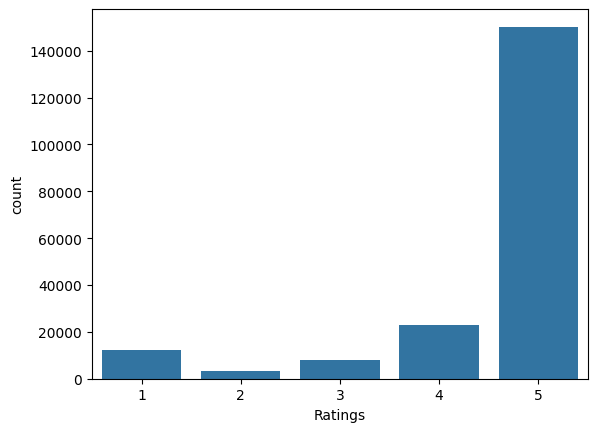

In [12]:
sns.countplot(x=df['Ratings']);

In [13]:
ybw=df[(df.Ratings==1) | (df.Ratings==5)]

In [14]:
ybw.reset_index(drop=True,inplace=True)

In [15]:
ybw.head()

,Review,Ratings
0,good,5
1,good,5
2,nice app,5
3,nice ig,5
4,this is a great app the bot is so accurate to ...,5


In [16]:
x=ybw[['Review']]
y=ybw[['Ratings']]

In [17]:
x.head()

,Review
0,good
1,good
2,nice app
3,nice ig
4,this is a great app the bot is so accurate to ...


In [18]:
y.head()

,Ratings
0,5
1,5
2,5
3,5
4,5


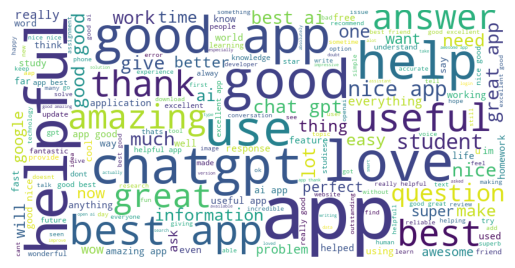

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(x['Review'].astype(str))
wc = WordCloud(background_color='white', width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [21]:
def ekkok(text):
    words=TextBlob(text).words
    return [word.lemmatize() for word in words]

In [22]:
vect=CountVectorizer(analyzer=ekkok,stop_words='english',ngram_range=(1,2))

In [23]:
from textblob import TextBlob

In [24]:
newx=vect.fit_transform(x['Review'])

C:\Users\furka\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
C:\Users\furka\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
tf = pd.DataFrame.sparse.from_spmatrix(
    vect.fit_transform(x['Review']), 
    columns=vect.get_feature_names_out()
)

In [26]:
tf

,a,aa,aaa,aaaa,aaaaaaaaaaaaaaa,aaaaaaaaaaaaaaaaaaàaaaaaaaaaaaaaaaaaaaaaaa,aaaaaaaaaaaaaaaaamazing,aaaaaaaaaaamazing,aaaaaaaaaamazing,aaaaaah,...,𝚗𝚒𝚌𝚎,𝚘𝚗𝚎,𝚘𝚙,𝚜𝚘𝚕𝚞𝚝𝚒𝚘𝚗,𝚜𝚝𝚊𝚍𝚢,𝚝𝚑𝚒𝚜,𝚝𝚘,𝚞𝚜𝚎𝚏𝚞𝚕,𝚟𝚊𝚛𝚢,𝚠𝚘𝚠
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162293,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
162294,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
162295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
162296,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
tf.shape

(162298, 38259)

In [28]:
x_train,x_test,y_train,y_test=train_test_split(newx,y, random_state=42, test_size=.10)

In [29]:
dt=DecisionTreeClassifier()

In [30]:
model=dt.fit(x_train,y_train)

In [31]:
predict=model.predict(x_test)

In [32]:
accuracy_score(y_test, predict)

0.9432532347504621

In [33]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Instantiate models
b = BernoulliNB()
l = LogisticRegression(max_iter=1000)
d = DecisionTreeClassifier()
r = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier()
kn = KNeighborsClassifier()
ab = AdaBoostClassifier()
mn = MultinomialNB()

def algo_test(x, y):
    models = [b, l, d, r, gb, kn, ab, mn]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "MultinomialNB"
    ]

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    accuracy, precision, recall, f1, trained_models = [], [], [], [], []

    print("Data ready. Starting model evaluation...\n")
    for model, name in zip(models, model_names):
        print(f"Training model: {name}...")
        
        # Fit model and predict
        fitted_model = model.fit(x_train, y_train)
        predictions = fitted_model.predict(x_test)
        
        # Store metrics (using average='weighted' for multi-class support)
        trained_models.append(fitted_model)
        accuracy.append(accuracy_score(y_test, predictions))
        precision.append(precision_score(y_test, predictions, average="weighted", zero_division=0))
        recall.append(recall_score(y_test, predictions, average="weighted", zero_division=0))
        f1.append(f1_score(y_test, predictions, average="weighted", zero_division=0))
        
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, predictions))
        print("Training completed.\n" + "-"*40)
    
    # Create results dataframe
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model_Object": trained_models
    }, index=model_names)

    # Sort by F1 Score
    metrics.sort_values(by="F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    print("Top Performing Model:", metrics.index[0])
    print("="*50)
    
    best_model = metrics.iloc[0]["Model_Object"]
    best_preds = best_model.predict(x_test)
    
    print("\nConfusion Matrix (Best Model):")
    print(confusion_matrix(y_test, best_preds))
    
    print("\nClassification Report (Best Model):")
    print(classification_report(y_test, best_preds, zero_division=0))
    
    print("\nAll Model Metrics:")
    return metrics.drop(columns=["Model_Object"])

In [34]:
algo_test(newx,y)

Data ready. Starting model evaluation...

Training model: BernoulliNB...
Confusion Matrix:
[[ 1069  1359]
 [ 1804 28228]]
Training completed.
----------------------------------------
Training model: LogisticRegression...


C:\Users\furka\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\furka\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[ 1361  1067]
 [  249 29783]]
Training completed.
----------------------------------------
Training model: DecisionTreeClassifier...
Confusion Matrix:
[[ 1369  1059]
 [  775 29257]]
Training completed.
----------------------------------------
Training model: RandomForestClassifier...


C:\Users\furka\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Confusion Matrix:
[[ 1246  1182]
 [  193 29839]]
Training completed.
----------------------------------------
Training model: GradientBoostingClassifier...


...

Confusion Matrix:
[[  718  1710]
 [  118 29914]]
Training completed.
----------------------------------------
Training model: AdaBoostClassifier...


C:\Users\furka\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[  520  1908]
 [  349 29683]]
Training completed.
----------------------------------------
Training model: MultinomialNB...
Confusion Matrix:
[[ 1418  1010]
 [  752 29280]]
Training completed.
----------------------------------------

Top Performing Model: LogisticRegression

Confusion Matrix (Best Model):
[[ 1361  1067]
 [  249 29783]]

Classification Report (Best Model):
              precision    recall  f1-score   support

           1       0.85      0.56      0.67      2428
           5       0.97      0.99      0.98     30032

    accuracy                           0.96     32460
   macro avg       0.91      0.78      0.83     32460
weighted avg       0.96      0.96      0.96     32460


All Model Metrics:


C:\Users\furka\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Accuracy,Precision,Recall,F1
LogisticRegression,0.959458,0.956432,0.959458,0.955624
RandomForestClassifier,0.957640,0.954715,0.957640,0.952566
MultinomialNB,0.945718,0.943228,0.945718,0.944311
DecisionTreeClassifier,0.943500,0.940643,0.943500,0.941878
GradientBoostingClassifier,0.943993,0.939385,0.943993,0.931471
KNeighborsClassifier,0.943685,0.939414,0.943685,0.930678
AdaBoostClassifier,0.930468,0.914080,0.930468,0.914909
BernoulliNB,0.902557,0.910535,0.902557,0.906283


Among all evaluated algorithms, Logistic Regression achieved the highest overall performance with an F1-Score of 95.56% and a Precision of 95.64%, closely followed by RandomForestClassifier with an Accuracy of 95.76%.

In [35]:
import joblib

In [36]:
joblib.dump(model,'lr_sentiment.pkl')

['lr_sentiment.pkl']